# Class Exercise 1 — Transfer learning with ResNet-18

#### **Student:** Héctor Zid Bonilla Correa / Usuario Cocyten 53

#### **Teacher:** Dr. German Alonso Pinedo Diaz

**Objective:** Configure and reason about three transfer learning regimes using the same pretrained ResNet-18:

1. **Linear probing** — training only the new classification head.
2. **Partial fine-tuning** — training the last residual stage (`layer4`) and the new head.
3. **Full fine-tuning** — training the entire network.

No full training execution is required. The emphasis is on the decisions that must be correct before training.

At the end of the exercise, you should be able to:

- identify the backbone and the task-specific head;
- control which parameters are trainable without rebuilding the model;
- verify what the optimizer will actually update;
- preserve the preprocessing expected by the pretrained weights;
- choose a sensible initial regime based on dataset size and source-target similarity;
- recognize when transfer learning may require more than just freezing or unfreezing layers.

## 0. Transfer learning in one image

A model pretrained on a large source task already contains useful visual representations.

\begin{equation}
\text{source data} \rightarrow \boxed{\text{pretrained backbone}} \rightarrow
\boxed{\text{source head}}
\end{equation}

For a new target task, we typically keep the backbone, replace the source head, and decide how much of the pretrained network to update:

\begin{equation}
\boxed{\text{pretrained backbone}} \rightarrow
\boxed{\text{new target head}}
\end{equation}

**Vocabulary**

- **Pretrained weights:** parameters learned on the source task.
- **Backbone / feature extractor:** the part that produces reusable representations.
- **Head:** task-specific output layers.
- **Fine-tuning:** continuing optimization from pretrained weights with target task data.
- **Negative transfer:** pretrained features may turn out to be unhelpful when the source and target problems are too different.

The practical question is not "Should I always adjust everything?" but "How much adaptation does the target task need?"

In [ ]:
import importlib.util
import subprocess
import sys

if importlib.util.find_spec("torchinfo") is None:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "torchinfo"])

import torch
import torch.nn as nn
from torchvision.models import resnet18, ResNet18_Weights
from torchinfo import summary

torch.manual_seed(0)

NUM_CLASSES = 5
weights = ResNet18_Weights.DEFAULT

# Load the pretrained source model. Torchvision downloads the weights once if needed.
try:
    model = resnet18(weights=weights)
    pretrained_available = True
    print("Loaded pretrained ResNet-18 weights.")
except Exception as error:
    # The structural exercises still run, but this fallback is not transfer learning.
    print("Pretrained weights unavailable:", type(error).__name__)
    print("Using random weights only so the architecture exercises can still run.")
    model = resnet18(weights=None)
    pretrained_available = False

in_features = model.fc.in_features
model.fc = nn.Linear(in_features, NUM_CLASSES)

summary(
    model,
    input_size=(1, 3, 224, 224),
    col_names=["input_size", "output_size", "num_params", "trainable"],
)

print("Feature dimension entering the new head:", in_features)
print("Target classes:", NUM_CLASSES)
print("True transfer learning:", pretrained_available)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 192MB/s]


Loaded pretrained ResNet-18 weights.
Feature dimension entering the new head: 512
Target classes: 5
True transfer learning: True


### Source preprocessing is part of the pretrained model

Pretrained features were learned under a particular input pipeline. A common mistake in transfer learning is to reuse the weights but ignore the preprocessing expected by those weights.

`weights.transforms()` provides the resizing, cropping, and normalization pipeline associated with these ResNet-18 weights. For a real target dataset, use it as the baseline preprocessing unless the target domain requires a deliberate change.

In [ ]:
preprocess = weights.transforms()
print(preprocess)

ImageClassification(
    crop_size=[224]
    resize_size=[256]
    mean=[0.485, 0.456, 0.406]
    std=[0.229, 0.224, 0.225]
    interpolation=InterpolationMode.BILINEAR
)


## 1. Trainability Utilities

Implement the functions below.

Requirements:

- change `requires_grad` only;
- do not recreate the backbone;
- do not replace `model.fc` again;
- each regime must be reproducible even if a previous cell changed the trainability.

The intended scopes are:

| Regime | Trainable modules |
|---|---|
| Linear prob | `fc` only |
| Partial fine-tuning | `layer4` + `fc` |
| Full fine-tuning | all parameters |

In [ ]:
def freeze_all(model):
    """Freeze every learnable parameter."""
    for p in model.parameters():
        p.requires_grad = False
    return model


def unfreeze_head(model):
    """Configure a linear probe: only model.fc is trainable."""
    # 1. Freeze everything just in case
    freeze_all(model)
    # 2. Unfreeze only the head
    for p in model.fc.parameters():
        p.requires_grad = True


def unfreeze_layer4(model):
    """Configure partial fine-tuning: model.layer4 and model.fc are trainable."""
    # 1. Freeze everything
    freeze_all(model)
    # 2. Unfreeze the last residual block (layer4)
    for p in model.layer4.parameters():
        p.requires_grad = True
    # 3. Unfreeze the head (fc)
    for p in model.fc.parameters():
        p.requires_grad = True


def reset_trainability(model):
    """Make every parameter trainable."""
    # Loop through all network parameters and enable them
    for p in model.parameters():
        p.requires_grad = True


def count_parameters(model):
    total = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return total, trainable


def trainable_parameter_names(model):
    return [name for name, p in model.named_parameters() if p.requires_grad]

## 2. Build and compare the three regimes

For each regime:

1. configure trainability;
2. count total and trainable parameters;
3. store the result in `results`;
4. inspect some trainable parameter names.

Your result must satisfy:

\[
N_{\text{linear probe}} < N_{\text{partial}} < N_{\text{full}}.
\]

The total parameter count must remain constant. Only the number of parameters receiving gradient updates should change.

In [ ]:
results = {}

# TODO: configure each regime and store (total_parameters, trainable_parameters).

# 1. Linear Probe: Head only
unfreeze_head(model)
results["linear_probe"] = count_parameters(model)

# 2. Partial Fine-tune: Layer 4 + head
unfreeze_layer4(model)
results["partial_finetune"] = count_parameters(model)

# 3. Full Fine-tune: Entire network
reset_trainability(model)
results["full_finetune"] = count_parameters(model)

for regime, counts in results.items():
    total, trainable = counts
    pct = 100.0 * trainable / total
    print(f"{regime:20s} total={total:>10,d}  trainable={trainable:>10,d}  ({pct:6.2f}%)")

linear_probe         total=11,179,077  trainable=     2,565  (  0.02%)
partial_finetune     total=11,179,077  trainable= 8,396,293  ( 75.11%)
full_finetune        total=11,179,077  trainable=11,179,077  (100.00%)


In [ ]:
# Optional self-check after you complete the previous cell.
if len(results) == 3:
    lp = results["linear_probe"][1]
    partial = results["partial_finetune"][1]
    full = results["full_finetune"][1]
    totals = {v[0] for v in results.values()}

    assert lp < partial < full, "Trainable parameter counts are not ordered as expected."
    assert len(totals) == 1, "The architecture should not change across regimes."
    print("Basic regime checks passed.")
else:
    print("Complete the three regimes first.")

Basic regime checks passed.


## 3. Verify what the optimizer will update

Freezing parameters and configuring the optimizer are related but distinct decisions.

A clean transfer learning pipeline passes only trainable parameters to the optimizer. This makes the scope of updates explicit and avoids silently keeping frozen parameters in the optimizer state.

Configure partial fine-tuning and create an optimizer using only trainable parameters.

Then verify:

$N_{\text{optimizer parameters}} = N_{\text{trainable parameters}}.$

**Optional extension:** use a smaller learning rate for the pretrained `layer4` and a larger one for the randomly initialized `fc` head. This is known as setting discriminative learning rates.

In [ ]:
import torch

# 1. Configure partial fine-tuning (Partial Fine-tune)
unfreeze_layer4(model)

# 2. Collect ONLY parameters that require gradients
trainable_params = [p for p in model.parameters() if p.requires_grad]

# 3. Create the optimizer passing only those parameters
optimizer = torch.optim.Adam(trainable_params, lr=1e-3)

# 4. Verify optimizer parameter count
optimizer_param_count = sum(p.numel() for group in optimizer.param_groups for p in group['params'])

print("Trainable parameter count:", count_parameters(model)[1])
print("Optimizer parameter count:", optimizer_param_count)

# --- OPTIONAL EXTENSION (Discriminative learning rates) ---
# If you wanted to implement the optional extension, the optimizer would look like this:
# optimizer = torch.optim.AdamW([
#         {"params": model.layer4.parameters(), "lr": 1e-4},
#         {"params": model.fc.parameters(), "lr": 1e-3},
#     ], weight_decay=1e-4)
# optimizer_param_count = sum(p.numel() for group in optimizer.param_groups for p in group['params'])

Trainable parameter count: 8396293
Optimizer parameter count: 8396293


## 4. Forward pass sanity check

Changing trainability should not alter tensor compatibility. The model should still map an RGB batch to five logits per image.

A forward pass verifies the architecture, not whether your transfer learning strategy is statistically sound.

In [ ]:
model.eval()

# 1. Detect which device (CPU or CUDA/GPU) the model is on
device = next(model.parameters()).device

# 2. Create tensor x and send it to that same device
x = torch.randn(2, 3, 224, 224).to(device)

with torch.no_grad():
    y = model(x)

print("Input shape :", tuple(x.shape))
print("Output shape:", tuple(y.shape))

assert y.shape == (2, NUM_CLASSES)

Input shape : (2, 3, 224, 224)
Output shape: (2, 5)


## A minimal transfer learning recipe for future projects

Use this sequence as your default experimental protocol:

1. **Choose a compatible pretrained model.** Match input modality and task as closely as possible.
2. **Use the source preprocessing as a baseline.**
3. **Replace the task-specific head.**
4. **Train a linear probe first.** It's cheap and tells you if the pretrained representation is already useful.
5. **Unfreeze progressively.** Move to the last stage and then the full model only if validation results justify the extra flexibility.
6. **Use smaller learning rates for pretrained weights** than for a newly initialized head when appropriate.
7. **Compare regimes on the same validation split.** Do not use the test set to choose the regime.
8. **Watch out for negative transfer.** If a carefully tuned pretrained model is consistently worse than a comparable randomly initialized baseline, the source representation may be poorly aligned with the target domain.

The best regime is an empirical choice, but the experiment must be structured so that the reason for switching regimes is visible in the validation behavior.

In [ ]:
from pathlib import Path

from torchvision import datasets
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

if not torch.cuda.is_available():
    raise RuntimeError(
        "A CUDA GPU is required. In Colab, select Runtime > Change runtime type > GPU, then restart."
    )

device = torch.device("cuda")
torch.backends.cudnn.benchmark = True
print(f"Using GPU: {torch.cuda.get_device_name(0)}")

# Create the datasets and data loaders before any training regime uses them.
image_net_transform = weights.transforms()
train_dataset = datasets.CIFAR10(
    root="/content/data",
    train=True,
    download=True,
    transform=image_net_transform,
)
test_dataset = datasets.CIFAR10(
    root="/content/data",
    train=False,
    download=True,
    transform=image_net_transform,
)

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True,
    num_workers=2,
    pin_memory=True,
    persistent_workers=True,
)
test_loader = DataLoader(
    test_dataset,
    batch_size=64,
    shuffle=False,
    num_workers=2,
    pin_memory=True,
    persistent_workers=True,
)

CHECKPOINT_DIR = Path("/content/checkpoints")
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)


def evaluate(model, loader, device):
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for inputs, targets in loader:
            inputs = inputs.to(device, non_blocking=True)
            targets = targets.to(device, non_blocking=True)
            logits = model(inputs)
            predictions = logits.argmax(dim=1)
            correct += (predictions == targets).sum().item()
            total += targets.size(0)
    return correct / total


def run_regime(name, setup_fn, train_loader, test_loader, epochs=10, lr=1e-3):
    cifar_model = resnet18(weights=weights)
    in_features = cifar_model.fc.in_features
    cifar_model.fc = nn.Linear(in_features, 10)
    setup_fn(cifar_model)
    cifar_model = cifar_model.to(device)

    trainable_params = [
        parameter for parameter in cifar_model.parameters() if parameter.requires_grad
    ]
    optimizer = torch.optim.AdamW(trainable_params, lr=lr)
    loss_fn = nn.CrossEntropyLoss()
    losses = []
    accuracies = []

    for epoch in range(1, epochs + 1):
        cifar_model.train()
        epoch_loss = 0.0
        epoch_correct = 0
        epoch_total = 0

        for inputs, targets in train_loader:
            inputs = inputs.to(device, non_blocking=True)
            targets = targets.to(device, non_blocking=True)
            optimizer.zero_grad(set_to_none=True)
            logits = cifar_model(inputs)
            loss = loss_fn(logits, targets)
            loss.backward()
            optimizer.step()

            epoch_loss += loss.item() * targets.size(0)
            epoch_correct += (logits.argmax(dim=1) == targets).sum().item()
            epoch_total += targets.size(0)

        average_loss = epoch_loss / epoch_total
        average_accuracy = epoch_correct / epoch_total
        losses.append(average_loss)
        accuracies.append(average_accuracy)
        print(
            f"{name} epoch {epoch:02d}/{epochs:02d} - "
            f"loss: {average_loss:.4f} - accuracy: {average_accuracy:.4f}"
        )

    test_accuracy = evaluate(cifar_model, test_loader, device)
    checkpoint_path = CHECKPOINT_DIR / f"m5_1_{name}.pt"
    torch.save(
        {
            "model_state_dict": cifar_model.state_dict(),
            "losses": losses,
            "accuracies": accuracies,
            "test_accuracy": test_accuracy,
        },
        checkpoint_path,
    )
    print(f"{name}: final test accuracy = {test_accuracy:.3f}")
    print(f"Checkpoint saved to: {checkpoint_path}")
    return losses, accuracies, test_accuracy


training_results = {}
for name, setup_fn in [
    ("linear_probe", unfreeze_head),
    ("partial_finetune", unfreeze_layer4),
    ("full_finetune", reset_trainability),
]:
    losses, accuracies, test_accuracy = run_regime(
        name,
        setup_fn,
        train_loader,
        test_loader,
        epochs=5,
        lr=1e-3,
    )
    training_results[name] = {
        "loss": losses,
        "accuracy": accuracies,
        "test_accuracy": test_accuracy,
    }
    torch.cuda.empty_cache()

Using GPU: Tesla T4


100%|██████████| 170M/170M [27:58<00:00, 102kB/s] 


linear_probe epoch 01/05 - loss: 0.8899 - accuracy: 0.7007
linear_probe epoch 02/05 - loss: 0.7150 - accuracy: 0.7520
linear_probe epoch 03/05 - loss: 0.6915 - accuracy: 0.7597
linear_probe epoch 04/05 - loss: 0.6852 - accuracy: 0.7606
linear_probe epoch 05/05 - loss: 0.6785 - accuracy: 0.7657
linear_probe: final test accuracy = 0.778
Checkpoint saved to: /content/checkpoints/m5_1_linear_probe.pt
partial_finetune epoch 01/05 - loss: 0.5432 - accuracy: 0.8161
partial_finetune epoch 02/05 - loss: 0.2977 - accuracy: 0.8988
partial_finetune epoch 03/05 - loss: 0.1923 - accuracy: 0.9335
partial_finetune epoch 04/05 - loss: 0.1270 - accuracy: 0.9555
partial_finetune epoch 05/05 - loss: 0.0939 - accuracy: 0.9675
partial_finetune: final test accuracy = 0.880
Checkpoint saved to: /content/checkpoints/m5_1_partial_finetune.pt
full_finetune epoch 01/05 - loss: 0.7142 - accuracy: 0.7558
full_finetune epoch 02/05 - loss: 0.4279 - accuracy: 0.8556
full_finetune epoch 03/05 - loss: 0.3227 - accuracy:

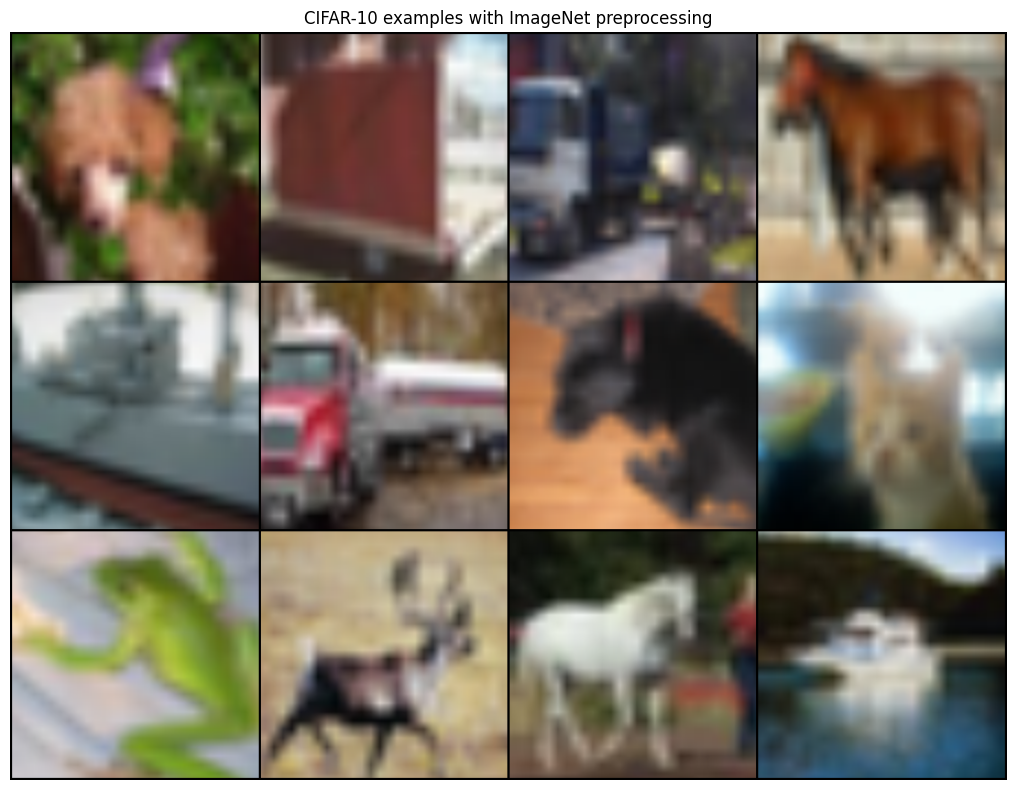

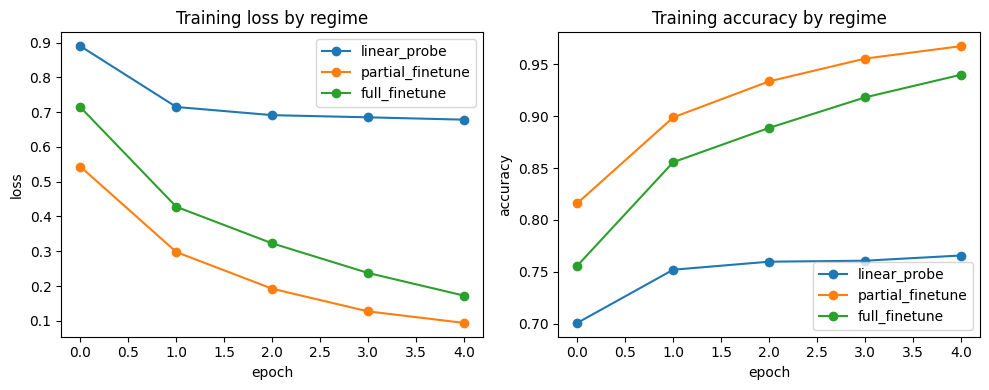

In [ ]:
from torchvision.utils import make_grid

# Display a 3-by-4 grid after reversing the ImageNet normalization.
images, labels = next(iter(train_loader))
mean = torch.tensor([0.485, 0.456, 0.406]).view(1, 3, 1, 1)
std = torch.tensor([0.229, 0.224, 0.225]).view(1, 3, 1, 1)
images_for_display = torch.clamp(images * std + mean, 0, 1)

grid = make_grid(images_for_display[:12], nrow=4, padding=2)
plt.figure(figsize=(12, 8))
plt.imshow(grid.permute(1, 2, 0).cpu())
plt.axis("off")
plt.title("CIFAR-10 examples with ImageNet preprocessing")
plt.tight_layout()
plt.show()

# Plot both training metrics in one dedicated figure.
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for name, information in training_results.items():
    axes[0].plot(information["loss"], marker="o", label=name)
    axes[1].plot(information["accuracy"], marker="o", label=name)

axes[0].set_title("Training loss by regime")
axes[0].set_xlabel("epoch")
axes[0].set_ylabel("loss")
axes[0].legend()

axes[1].set_title("Training accuracy by regime")
axes[1].set_xlabel("epoch")
axes[1].set_ylabel("accuracy")
axes[1].legend()

plt.tight_layout()
plt.show()